# scWAT Xenium QC - Region_4

## Goal

Run reproducible, non-destructive technical QC for **Region_4**. This notebook is one of four structurally identical region notebooks; its region identifier is locked below. Full-data results must be produced on HPC. Local runs use a deterministic small subset only and cannot establish transcript-level or final slide readiness.


## Setup

The cell below defines HPC defaults and accepts explicit environment overrides for local subset validation. It refuses writable paths outside `adipose_analysis`. The pipeline installs nothing; missing packages cause a clear preflight stop.


In [1]:
REGION_ID <- "Region_4"
EXECUTION_MODE <- toupper(Sys.getenv("SCWAT_QC_MODE", "FULL_HPC"))
stopifnot(EXECUTION_MODE %in% c("FULL_HPC", "LOCAL_SUBSET"))
PROJECT_ROOT <- Sys.getenv("SCWAT_PROJECT_ROOT", "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium")
PIPELINE_REPO <- Sys.getenv("SCWAT_PIPELINE_REPO", file.path(PROJECT_ROOT, "adipose_analysis_B2", "YNH_Xenium_scWAT"))
INPUT_ROOT <- Sys.getenv("SCWAT_INPUT_ROOT", file.path(PROJECT_ROOT, "adipose_data_B2"))
RUN_LABEL <- Sys.getenv("SCWAT_RUN_LABEL", "scwat_qc_hpc")
RUN_ROOT <- Sys.getenv("SCWAT_RUN_ROOT", file.path(PROJECT_ROOT, "adipose_analysis_B2", "scwat_qc_outputs", RUN_LABEL))
TEMP_ROOT <- Sys.getenv("SCWAT_TEMP_ROOT", file.path(PROJECT_ROOT, "adipose_analysis_B2", "tmp", RUN_LABEL))
dir.create(TEMP_ROOT, recursive = TRUE, showWarnings = FALSE)
Sys.setenv(TMPDIR = TEMP_ROOT, TMP = TEMP_ROOT, TEMP = TEMP_ROOT)
source(file.path(PIPELINE_REPO, "R", "source.R"))
set.seed(20260814L)


### Key assumptions

All four regions use one installed Xenium panel. Mouse is the biological replicate; Regions 1–2 are sections from Mouse 1 and Regions 3–4 are sections from Mouse 2. No left/right or treatment factor is defined. This notebook performs technical QC only. The primary cell cohort is prespecified as `5 < nFeature_Xenium < 200` and `10 < nCount_Xenium < 1000`. Segmentation, nucleus, area, control, and spatial findings remain separate review flags.


In [2]:
runtime <- validate_runtime_paths(project_root = PROJECT_ROOT, input_root = INPUT_ROOT, output_root = RUN_ROOT, temp_root = TEMP_ROOT)
regions <- discover_xenium_sections(INPUT_ROOT, expected_section_count = 4L)
stopifnot(identical(regions$region_id, expected_scwat_regions()))
manifest <- utils::read.delim(file.path(PIPELINE_REPO, "config", "scwat_sample_manifest.tsv"), check.names = FALSE)
manifest_check <- validate_sample_manifest(manifest, expected_scwat_regions())
stopifnot(isTRUE(manifest_check$valid))
fixed_thresholds <- read_fixed_cell_qc_thresholds(file.path(PIPELINE_REPO, "config", "fixed_cell_qc_thresholds.tsv"))
manifest[manifest$region_id == REGION_ID, , drop = FALSE]


,tissue,region_id,mouse_id,section_id,biological_replicate_id,technical_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret,notes
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>
4,scWAT,Region_4,Mouse_2,62311,Mouse_2,Region_4,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62311; no left/right factor


## Inputs and integrity

Discover the region directory from its identifier, inventory required files, and verify matrix/metadata alignment before loading counts. Raw data are read-only. Full transcript Parquet is not collected into memory; later full-HPC transcript summaries must use Arrow-backed aggregation.


In [3]:
region_record <- discover_one_section(INPUT_ROOT, REGION_ID)
region_dir <- region_record$region_dir[[1L]]
inventory <- inventory_section_files(region_dir, REGION_ID, calculate_md5 = FALSE)
integrity <- validate_section_integrity(region_dir, REGION_ID)
stopifnot(all(inventory$exists), isTRUE(integrity$dimension_match[[1L]]))
bundle <- import_xenium_mex(region_dir)
stopifnot(inherits(bundle$counts, "sparseMatrix"), identical(colnames(bundle$counts), bundle$cells$cell_id))


## Cell QC

Compute targeted-panel complexity, control burden, and segmentation review fields without deleting cells. Exact boundary values 5/200 features and 10/1000 counts fail. `primary_include` contains only the fixed rule; `strict_include` additionally excludes all review flags.


In [4]:
cell_qc <- calculate_xenium_cell_qc(bundle$counts, bundle$cells, REGION_ID, fixed_thresholds)
masks <- build_cell_downstream_masks(cell_qc$cell_metadata, provenance = paste(RUN_LABEL, EXECUTION_MODE, sep = "::"))
stopifnot(nrow(masks) == ncol(bundle$counts), all(!masks$strict_include | masks$primary_include))
table(primary_include = masks$primary_include, strict_include = masks$strict_include)


               strict_include
primary_include FALSE  TRUE
          FALSE  1222     0
          TRUE   1295 47922

## Outputs and checks

Write an auditable region bundle beneath the run root: sparse raw counts, all cell metadata and masks, thresholds, inventory/integrity, run configuration, readiness evidence, and session information. The source notebook stays output-free; executed copies belong under the run directory.


In [5]:
section_output_dir <- file.path(RUN_ROOT, "sections", REGION_ID)
result <- write_scwat_region_qc_bundle(
  project_root = PROJECT_ROOT, output_dir = section_output_dir, region_id = REGION_ID,
  run_label = RUN_LABEL, execution_mode = EXECUTION_MODE, manifest = manifest,
  inventory = inventory, integrity = integrity, bundle = bundle, cell_qc = cell_qc, masks = masks
)
stopifnot(validate_scwat_region_qc_bundle(section_output_dir, REGION_ID))
result


region_id,output_dir,cells,primary_include,cells_deleted
<chr>,<chr>,<int>,<int>,<int>
Region_4,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis_B2/scwat_qc_outputs/scwat_qc_hpc/sections/Region_4,50439,49217,0


In [6]:
# QC review flag - nucleus_missing | segmentation_multiplet | area_outlier | high_control | !qc_core_pass
qc_plots = plot_section_qc(masks, REGION_ID)

In [7]:
options(repr.plot.width=6, repr.plot.height=4)

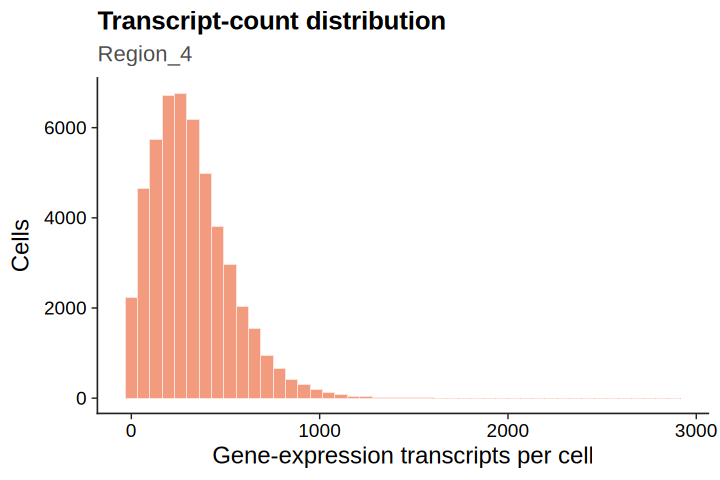

In [8]:
qc_plots$counts

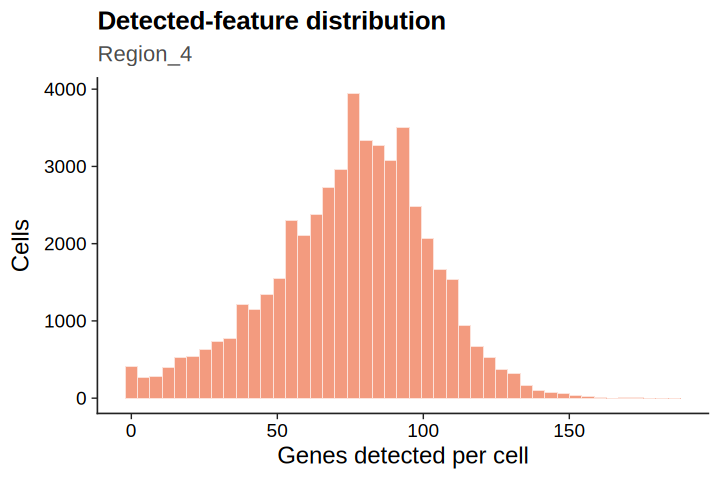

In [9]:
qc_plots$features

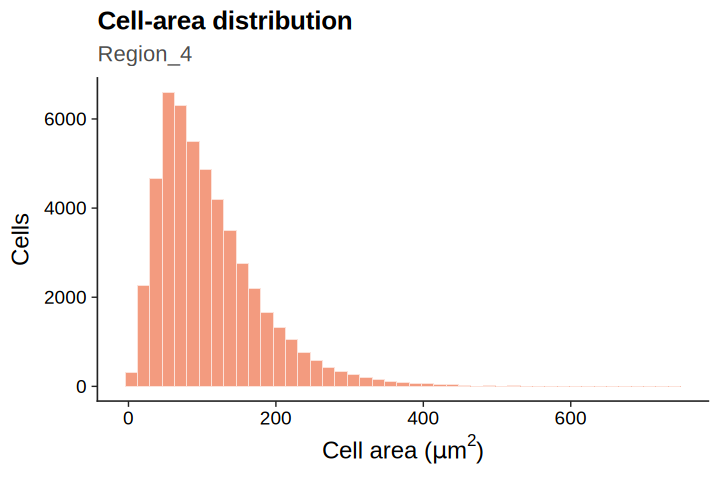

In [10]:
qc_plots$area

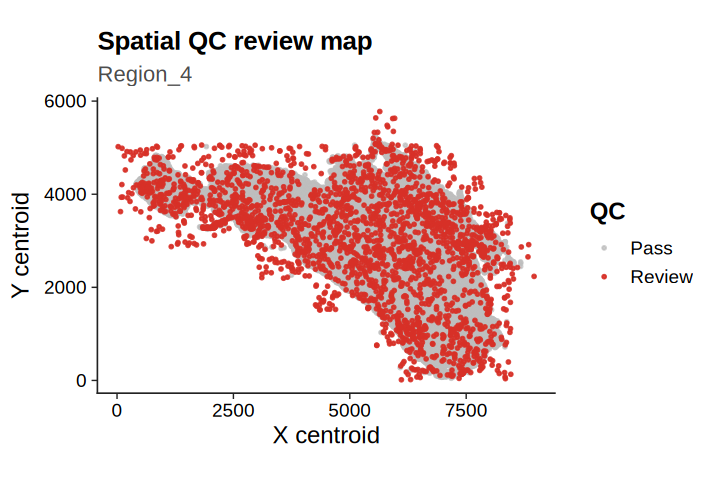

In [11]:
qc_plots$spatial

## Next steps

Review region tables and figures, especially assignment/control burden, boundary counts, segmentation flags, and spatial patterns. A `PASS` here is technical evidence only. After all four regions finish under the same run label and mode, execute `02_slide_QC_summary.ipynb`. Full-data HPC output—not a local subset—determines final readiness before the separate Region 3 anchor workflow.
